# Theory Of Logistic Regression

In [ ]:
# Logistic Regression 
# 1. Why we need to move from liner to Logistic 
# 2. Why it is called Logistic Regression 
# 3. Math behind Logistic Regression 
# 4. Sigmoid function 
# 5. Understanding m and c values 
# 6. Confusion Matrix 
# 7. Evalutaion Matrix 
# 8. End to end Logistic Regression 
# 9. Real time example



In [12]:
# 1. Why we need to move from Liner to Logistic

# Linear Reg predicts continuous values
# ex : HousePricePred , SalaryPred , MarksPred
# 1,2,3,4,5,5,6,6

# Logistic stuff is used for yes or no kinda things 
# like spam detc , pass fail 
# 0 , 1

In [ ]:
# 2. Why it is called Logistic Regression 

# This uses a regression equation internally , which is 
# z = mx+c 
# then ,
# y = 1 / 1 + e^-z
# this convert values from : -infi to +infi to 0 to 1
# it preforms classification using regressino mathematics

In [ ]:
# 3. Math behind Logistic Regression 

# z = mx + c 
# where : 
# m = slope
# c = intercetp 
# x = intput feature 
# z = pred value 

# then 
# z = 2x -6 

# code 
# x = 4 
# then 
# z = 2 * 4 -6 

# sigmoid function calculation 
# z = 2 
# y = 1 / 1 + e^-2
# if prob > 0.5 
# class -> 1 
# or class -> 0


In [14]:
# 3 
import math
z = 4 
sig = 1 / 1+math.exp(-z)
print(z)
print(sig)
prb = sig
if prb > 0.5:
    print("pass")
else:
    print("fail")
    

4
1.0183156388887342
pass


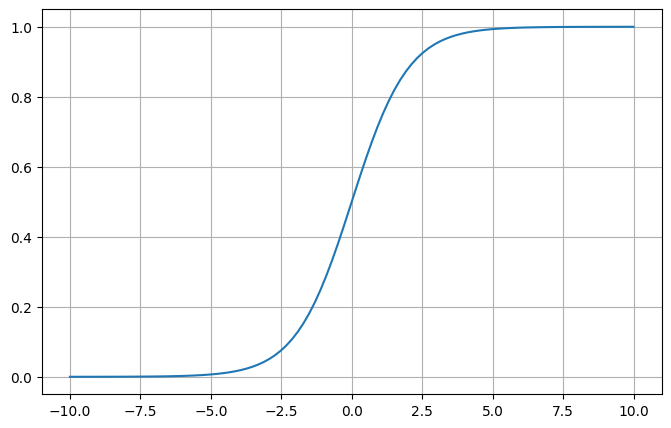

In [17]:
# Visualizing the sigmoid curve 
import matplotlib.pyplot as plt 
import numpy as np

x = np.linspace(-10, 10, 100)
y = 1/ (1+ np.exp(-x))
plt.figure(figsize = (8, 5))
plt.plot(x,y)
plt.grid()
plt.show()

In [ ]:
# Confusion Matrix

actual  prediceted  result 
 1         1          TP 
 1         0          FN
 0         1          FP
 0         0          TN

# Evaluation metrics 
# 1. accuracy TP + TN / total 
# 2. precision TP / TP + FP
# 3. recall  TP / TP + FN
# 4. f1-score 2 * (pres * recall) / pres + recall


In [ ]:
# Logistic Regression end to end 



In [22]:
import pandas as pd 
import numpy as np 

data = {
    "Stdy" : [1,2,3,4,5,6,7,8,9,10],
    "Pass" : [0,0,0,0,1,1,1,1,1,1]
}

In [24]:
df = pd.DataFrame(data)
df.head()

,Stdy,Pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1


In [25]:
x = df[["Stdy"]]
y = df[["Pass"]]

In [27]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x, y , test_size=0.2)

In [29]:
X_train.shape , X_test.shape

((8, 1), (2, 1))

In [30]:
from sklearn.linear_model import LogisticRegression
logR = LogisticRegression()
logR.fit(X_train , y_train)

C:\Users\SriHarshaK\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
m = logR.coef_[0][0]
c = logR.intercept_[0]
m,c

(np.float64(1.0755804893636696), np.float64(-4.6177290568180425))

In [33]:
x = 5 
z = m *x +c 

prb = 1/ (1+math.exp(-z))
print(prb)

if prb>0.6:
    print("pass")
else:
    print("fail")
# pred = model.predict(x_test)


0.6813913774509373
pass


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
accuracy = accuracy_score(y_test,pred)
precision = precision_score(y_test,pred)
recall = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
clas=classification_report(y_test,pred)
print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall: ",recall)
print("F1 Score: ",f1)
print("Classification Report: \n",clas)